In [9]:
import numpy as np
from scipy.optimize import least_squares

## Teoria

Estimacion del coeficiente de reflexion de la fuente (Gamma_s, "source match") de un generador de senales, con el setup de acoplador direccional + linea de transmision (carga deslizante / offset loads), siguiendo el metodo de Furrer/de Vreede con trazabilidad metrologica (Juroshek, NPL):

https://www.researchgate.net/publication/333078487_Measuring_Signal_Generator_Source_Match

SETUP DE MEDICION
-------------------

El generador alimenta un acoplador direccional; en el brazo acoplado se mide
potencia escalar (medidor de potencia / analizador de espectro). En la salida
del acoplador direccional, se conecta una carga con $\Gamma_L$ (magnitud y fase) 
variable. Para realizar mediciones similares al paper, la carga será una linea de 
transmisión con longitud variable conectada al otro extremo en *Short* o en *Open*.

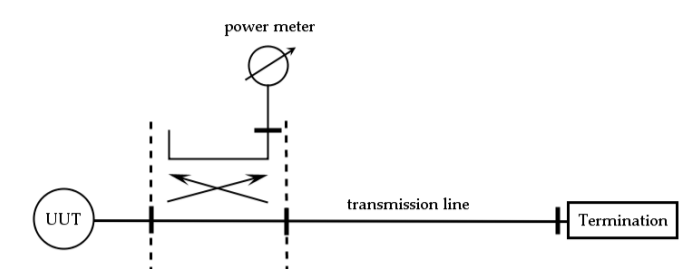

METODO DE MEDICION
-------------------

* Se caracteriza el conjunto acoplador direccional y carga (linea de transmisión) con un VNA.
* Se conecta el DUT al setup de medición.
* Se realiza la medición de potencia.
* Se repite el proceso con todas las cargas.  

MODELO MATEMÁTICO
-------------------

La potencia medida por el conjunto, luego de realizar grafos y resolver, presenta la siguiente ecuación:

$$P = P_g\,\frac{|S_{21}|^2\,(1-|\Gamma_s|^2)}{\left|(1-\Gamma_g S_{11})(1-\Gamma_s S_{22}) - \Gamma_g\Gamma_s S_{12}S_{21}\right|^2}$$

Se obtiene el valor de $\Gamma_g$ con métodos regresivos, minimizando la ecuación obtenida 
con distintos valores de $\Gamma_g$.


INCERTIDUMBRE:
----------------------

La incertidumbre en el paper fue calculada utilizando software específico
para la propagación de error, basado en metodologías GUM indicadas en papers previos.


LEY DE PROPAGACION BIVARIANTE (Ridler & Salter, Metrologia 39, 2002)


El resultado theta_hat = (Re(Gamma_s), Im(Gamma_s), P0) no es una funcion cerrada de las entradas: es la solucion de un ajuste no lineal. El GUM (seccion 5.1.4 / Supplement 2) indica que cuando el "modelo" es un algoritmo/procedimiento, los coeficientes de sensibilidad c_k = d(theta)/d(u_k) se obtienen evaluando como cambia el resultado ante variaciones de cada entrada -- aqui se obtienen por diferenciacion implicita de la condicion de optimo del ajuste (aproximacion de Gauss-Newton, la misma que usa cualquier software de regresion no lineal para el error estandar de los parametros, aqui generalizada a "errors-in-variables" porque Gamma_L,i tambien es incierto):


    En el optimo:            J_theta^T @ r(theta, u) = 0
    Derivando respecto a u:  J_theta^T @ (J_theta @ dtheta + J_u @ du) = 0    =>  d(theta)/d(u) = S = -(J_theta^T J_theta)^-1 J_theta^T J_u


donde J_theta = d(residuos)/d(theta) (Jacobiano del ajuste, en el optimo) y J_u = d(residuos)/d(entradas) (sensibilidad del modelo a cada Gamma_L,i y cada P_i medidos). Luego:


    Cov(theta_hat) = S @ Cov(u) @ S^T


Esto es exactamente la "ley de propagacion" (LPU) generalizada de forma
bivariante: una matriz de covarianza real 2x2 (o 3x3 con P0) en lugar de una
varianza escalar, tal como formulan Ridler & Salter para S-parametros
complejos.

## Resolución

### Funciones Auxiliares

In [10]:
# Combina todos los datos en un "paquete"
# X = [Re/Im S11 (N), Re/Im S21 (N), Re/Im S12 (N), Re/Im S22 (N), Re/Im Gs, P (N)]
def pack(S11 : complex, S21 : complex, S12 : complex, S22 : complex, Gs : complex, P : int):
    '''pack
    empaqueta todos los datos en una única variable
    
    Params
    ---
    S11 : '''
    parts = []
    for S in (S11, S21, S12, S22):
        parts += [np.real(S), np.imag(S)]
    parts += [np.array([Gs.real, Gs.imag]), np.asarray(P, float)]
    return np.concatenate(parts)

def unpack(X : list, N : int):
    '''unpack
    Separa los datos empaquetados.

    Params
    ---
    X : list    
        Paquete de datos a desempaquetar.
    N : int
        Cantidad de paquetes.
    '''
    S = []
    for k in range(4):
        S.append(X[2 * k * N:(2 * k + 1) * N] + 1j * X[(2 * k + 1) * N:(2 * k + 2) * N])
    Gs = X[8 * N] + 1j * X[8 * N + 1]
    P = X[8 * N + 2:8 * N + 2 + N]
    return S[0], S[1], S[2], S[3], Gs, P
  
def groups(N):
    """Indices de X por grupo (para el presupuesto de incertidumbre)."""
    return {
        "S-parametros (VNA)": np.arange(0, 8 * N),
        "Gamma_s del sensor": np.arange(8 * N, 8 * N + 2),
        "Potencias P_i": np.arange(8 * N + 2, 9 * N + 2),
    }

def tabla(headers, rows):
    """Tabla ASCII simple: primera columna a la izquierda, el resto a la derecha."""
    w = [max(len(str(h)), *(len(str(r[i])) for r in rows)) for i, h in enumerate(headers)]
    sep = "+" + "+".join("-" * (a + 2) for a in w) + "+"
 
    def fila(r):
        celdas = [str(c).ljust(a) if i == 0 else str(c).rjust(a)
                  for i, (c, a) in enumerate(zip(r, w))]
        return "| " + " | ".join(celdas) + " |"
 
    return "\n".join([sep, fila(headers), sep] + [fila(r) for r in rows] + [sep])
 
 
def titulo(txt):
    print("\n" + txt)
    print("=" * len(txt))

### Estimación de Valor

In [11]:
def model_power(Gg, Pg, Gs, S11, S21, S12, S22):
    den = (1 - Gg * S11) * (1 - Gs * S22) - Gg * Gs * S12 * S21
    return Pg * np.abs(S21) ** 2 * (1 - np.abs(Gs) ** 2) / np.abs(den) ** 2
 

def _fit(X : list, N : int, theta0, Pscale):
    S11, S21, S12, S22, Gs, P = unpack(X, N)
    Pn = P / Pscale
 
    def resid(th):
        return model_power(th[0] + 1j * th[1], th[2], Gs, S11, S21, S12, S22) - Pn
 
    return least_squares(resid, theta0,
                         bounds=([-0.999, -0.999, 1e-12], [0.999, 0.999, np.inf]),
                         method="trf", x_scale="jac",
                         xtol=1e-15, ftol=1e-15, gtol=1e-15)
 
def fit_gamma_g(X : list, N : int, n_starts : int = 30, seed : int = 0):
    """Ajuste global con multi-arranque. Devuelve theta=(x,y,pg_normalizado), Pscale, res."""
    P = unpack(X, N)[5]
    Pscale = np.mean(P)
    S11, S21, S12, S22, Gs, _ = unpack(X, N)
    pg0 = np.mean(P / (np.abs(S21) ** 2 * (1 - abs(Gs) ** 2))) / Pscale
    rng = np.random.default_rng(seed)
    best = None
    for k in range(n_starts):
        g0 = [0.0, 0.0] if k == 0 else list(rng.uniform(-0.4, 0.4, 2))
        res = _fit(X, N, g0 + [pg0], Pscale)
        if best is None or res.cost < best.cost:
            best = res
    return best.x, Pscale, best


### Incertdumbre

In [12]:
def uncertainty(X : list, N : int , cov_X, theta, Pscale, res, step=1e-6):
    """
    Propagacion tipo Hall:
      (a) sensibilidad de theta a cada magnitud de influencia X_k
          (derivada de la funcion implicita, evaluada por re-ajuste con
          diferencias centrales):  d theta / d X_k = -(dF/dX_k)/(dF/d theta)
      (b) componente de residuos: s^2 (J^T J)^-1, s^2 = h_min/(N - p)
    cov_X: matriz de covarianza de X (diagonal si no hay correlaciones).
    Devuelve covarianza de (x, y, Pg[W]) y presupuesto por grupo.
    """
    nX = len(X)
    Sens = np.zeros((3, nX))
    for k in range(nX):
        Xp, Xm = X.copy(), X.copy()
        h = step * max(1.0, abs(X[k]))
        Xp[k] += h
        Xm[k] -= h
        tp = _fit(Xp, N, theta, Pscale).x
        tm = _fit(Xm, N, theta, Pscale).x
        Sens[:, k] = (tp - tm) / (2 * h)
 
    # pasar pg (normalizado) a Pg en W
    scale = np.diag([1.0, 1.0, Pscale])
    Sens_W = scale @ Sens
 
    cov_inputs = Sens_W @ cov_X @ Sens_W.T
 
    # componente de residuos (ec. 7 generalizada a 3 parametros)
    p = 3
    J = res.jac
    s2 = 2 * res.cost / max(N - p, 1)
    cov_res = scale @ (s2 * np.linalg.pinv(J.T @ J)) @ scale.T
 
    budget = {}
    for name, idx in groups(N).items():
        Sg = Sens_W[:, idx]
        budget[name] = Sg @ cov_X[np.ix_(idx, idx)] @ Sg.T
    budget["Calidad del ajuste (residuos)"] = cov_res
 
    return cov_inputs + cov_res, budget, np.sqrt(s2)

## Ejemplo

In [13]:
def build_networks(f=1e9, eps_r=2.05, loss_db_per_m=0.3):
    """8 redes: largos 0/70/100/150 cm x (open, short). Valores INVENTADOS."""
    c0 = 299792458.0
    beta = 2 * np.pi * f / (c0 / np.sqrt(eps_r))
    alpha = loss_db_per_m / 8.686
    Gm = 0.04 * np.exp(1j * 0.6)      # desadaptacion del acoplador (puerto 1)
    G2 = 0.02 * np.exp(1j * 2.0)      # desadaptacion del brazo monitor
    t, c = 0.98, 0.10                 # transmision directa, acoplamiento (-20 dB)
    d = 0.03 * np.exp(-1j * 1.0)      # fuga por directividad finita
    S11, S21, S22 = [], [], []
    for l in (0.0, 0.70, 1.00, 1.50):
        for T in (+0.98, -0.98):      # open / short
            GL = T * np.exp(-2 * (alpha + 1j * beta) * l)
            S11.append(Gm + t ** 2 * GL)
            S21.append(c * (d + GL))
            S22.append(G2)
    S11, S21, S22 = map(np.array, (S11, S21, S22))
    return S11, S21, S21.copy(), S22   # reciprocidad: S12 = S21
 
 
if __name__ == "__main__":
    rng = np.random.default_rng(1)
 
    # Valores Verdaderos
    Gg_true, Pg_true = 0.05 + 0.03j, 2e-3
    Gs_true = 0.02 - 0.01j
    S11t, S21t, S12t, S22t = build_networks()
    N = len(S11t)
    P_true = model_power(Gg_true, Pg_true, Gs_true, S11t, S21t, S12t, S22t)
 
    # Incertidumbres de Instrumental
    u_S = 0.003          # por componente re/im de cada S-parametro (VNA)
    u_Gs = 0.005         # por componente de Gamma_s
    u_Prel = 0.002       # relativa de cada lectura de potencia (0.2 %)
 
    # Valores medidos (Real + ruido)
    X_true = pack(S11t, S21t, S12t, S22t, Gs_true, P_true)
    u = np.concatenate([np.full(8 * N, u_S), [u_Gs, u_Gs], u_Prel * P_true])
    X = X_true + u * rng.standard_normal(len(X_true))
    cov_X = np.diag(u ** 2)          # sin correlaciones (ver nota en la respuesta)
 
    # Estimación de Gamma
    theta, Pscale, res = fit_gamma_g(X, N)
    Gg = theta[0] + 1j * theta[1]
    Pg = theta[2] * Pscale

    # Incertidumbre de Gamma
    cov, budget, s = uncertainty(X, N, cov_X, theta, Pscale, res)
    u_re, u_im = np.sqrt(cov[0, 0]), np.sqrt(cov[1, 1])
    rho = cov[0, 1] / (u_re * u_im)

    # Verificacion por Monte Carlo (solo valida la parte de magnitudes de entrada)
    draws = []
    for _ in range(300):
        Xd = X + u * rng.standard_normal(len(X))
        r = _fit(Xd, N, theta, Pscale)
        draws.append(r.x[:2])
    draws = np.array(draws)
    sens_only = cov  # incluye residuos; para comparar usamos solo la parte de entradas
    C_in = sum(v for k, v in budget.items() if "residuos" not in k)


    # Cálculo de Módulo y Fase
    x, y, m = Gg.real, Gg.imag, abs(Gg)
    g_mag = np.array([x / m, y / m, 0.0])
    g_fase = np.array([-y / m ** 2, x / m ** 2, 0.0]) * 180 / np.pi
    g_pg = np.array([0.0, 0.0, 1.0])
    u_of = lambda g: float(np.sqrt(g @ cov @ g))
    fase_t, fase_e = np.degrees(np.angle(Gg_true)), np.degrees(np.angle(Gg))
    # (nombre, original, estimado, u, formato)
    filas_def = [
        ("Re(Gamma_g)",   Gg_true.real,  Gg.real,  np.sqrt(cov[0, 0]), ".4f"),
        ("Im(Gamma_g)",   Gg_true.imag,  Gg.imag,  np.sqrt(cov[1, 1]), ".4f"),
        ("|Gamma_g|",     abs(Gg_true),  m,        u_of(g_mag),         ".4f"),
        ("fase [deg]",    fase_t,        fase_e,   u_of(g_fase),        ".2f"),
        ("Pg [mW]",       Pg_true * 1e3, Pg * 1e3, u_of(g_pg) * 1e3,    ".4f"),
    ]

    # Respuesta:
    titulo("Estimacion de Gamma_g - metodo de Hall/Furrer (datos simulados)")
 
    print("\nValor original")
    print(f"  Gamma_g = {Gg_true.real:+.4f} {Gg_true.imag:+.4f}j"
          f"   (|G| = {abs(Gg_true):.4f}, fase = {fase_t:.2f} deg)")
    print(f"  Pg      = {Pg_true*1e3:.4f} mW")
 
    print("\nResultados: original vs. estimado")
    rows = []
    for nombre, orig, est, ux, f in filas_def:
        err = est - orig
        rows.append((nombre, format(orig, f), format(est, f), format(err, "+" + f),
                     format(ux, f), format(2 * ux, f), f"{abs(err) / (2 * ux):.2f}"))
    print(tabla(["Magnitud", "Original", "Estimado", "Error", "u (k=1)", "U (k=2)", "|Error|/U"], rows))
    print("  |Error|/U < 1  ->  el valor original cae dentro de la incertidumbre expandida")
    rho = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    print(f"  Correlacion Re-Im = {rho:+.2f}   |   residuo tipico s = {s:.2e} (normalizado)")
 
    print("\nPresupuesto de incertidumbre")
    vr, vi = cov[0, 0], cov[1, 1]
    rows = [(nombre, f"{np.sqrt(C[0, 0]):.4f}", f"{np.sqrt(C[1, 1]):.4f}",
             f"{100 * C[0, 0] / vr:5.1f} %", f"{100 * C[1, 1] / vi:5.1f} %")
            for nombre, C in budget.items()]
    rows.append(("TOTAL", f"{np.sqrt(vr):.4f}", f"{np.sqrt(vi):.4f}", "100.0 %", "100.0 %"))
    print(tabla(["Fuente", "u(Re)", "u(Im)", "var(Re)", "var(Im)"], rows))
 
    print("\nVerificacion Monte Carlo (300 sorteos, solo magnitudes de entrada)")
    mc = draws.std(axis=0, ddof=1)
    an = np.sqrt([C_in[0, 0], C_in[1, 1]])
    rows = [(nm, f"{a:.4f}", f"{b:.4f}", f"{100 * (b - a) / a:+.1f} %")
            for nm, a, b in zip(["u(Re)", "u(Im)"], an, mc)]
    print(tabla(["Magnitud", "Analitico", "Monte Carlo", "Dif. rel."], rows))



Estimacion de Gamma_g - metodo de Hall/Furrer (datos simulados)

Valor original
  Gamma_g = +0.0500 +0.0300j   (|G| = 0.0583, fase = 30.96 deg)
  Pg      = 2.0000 mW

Resultados: original vs. estimado
+-------------+----------+----------+---------+---------+---------+-----------+
| Magnitud    | Original | Estimado |   Error | u (k=1) | U (k=2) | |Error|/U |
+-------------+----------+----------+---------+---------+---------+-----------+
| Re(Gamma_g) |   0.0500 |   0.0432 | -0.0068 |  0.0235 |  0.0470 |      0.14 |
| Im(Gamma_g) |   0.0300 |   0.0439 | +0.0139 |  0.0304 |  0.0609 |      0.23 |
| |Gamma_g|   |   0.0583 |   0.0616 | +0.0033 |  0.0244 |  0.0488 |      0.07 |
| fase [deg]  |    30.96 |    45.43 |  +14.46 |   27.70 |   55.39 |      0.26 |
| Pg [mW]     |   2.0000 |   2.0236 | +0.0236 |  0.0672 |  0.1344 |      0.18 |
+-------------+----------+----------+---------+---------+---------+-----------+
  |Error|/U < 1  ->  el valor original cae dentro de la incertidumbre expandid